In [26]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np

patch_size = 20

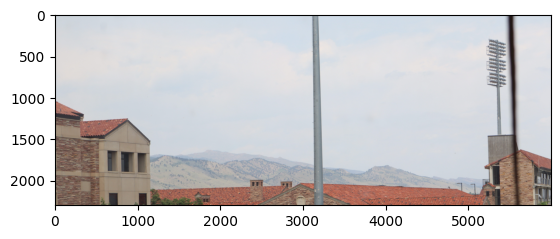

In [71]:
# Traverse over the pixels in the image in chunks
# Analyzing them two at a time just for the sake of this, but I think there
# are probably better solutions we can come up with eventually
# Especially with the need for interpolation

# Maybe make an array as like a map of what all the values are comparing the A_hat between all lateral patches
# Then somehow mesh this, if it's working decently



# Reading in the image
image = cv.imread("EOS_R100_JPG/jpg0005.jpg")
image = image[:,:,::-1]
image = image[:2300,:]
plt.imshow(image)

In [68]:
# Helper Functions

def lobf(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    # I'm guessing that the total range is 0-255, but don't really have proof of that
    fit, inliers= ransac(pixels, LineModelND, 200, 2, max_trials = 1000) 
    return (fit, inliers)

def polyfit(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    polyfit_x = np.polyfit(pixels[:][:,2], pixels[:][:,0], 1)
    polyfit_y = np.polyfit(pixels[:][:,2], pixels[:][:,1], 1)
    return[polyfit_x, polyfit_y]

def display_lobf(lobf):
    """TO IMPLEMENT"""
    return None

def normalize(vec):
    l = np.sqrt(vec[0]**2 + vec[1]**2+vec[2]**2)
    return [vec[0]/l, vec[1]/l, vec[2]/l]

def airlight_direction(lobf_one, lobf_two):
    # z1 = [50]
    # z2 = [100]
    z1 = 50
    z2 = 100

    # points on plane 1
    # pt1 = [lobf_one.predict_x(z1)[0], lobf_one.predict_y(z1)[0], z1[0]]
    # pt2 = [lobf_one.predict_x(z2)[0], lobf_one.predict_y(z2)[0], z2[0]]
    pt1 = [z1*lobf_one[0][0] + lobf_one[0][1], z1*lobf_one[1][0] + lobf_one[1][1], z1]
    pt2 = [z2*lobf_one[0][0] + lobf_one[0][1], z2*lobf_one[1][0] + lobf_one[1][1], z1]
    norm_one = np.cross(pt1, pt2)
    # points on plane 2
    pt3 = [z1*lobf_two[0][0] + lobf_two[0][1], z1*lobf_two[1][0] + lobf_two[1][1], z2]
    pt4 = [z2*lobf_two[0][0] + lobf_two[0][1], z2*lobf_two[1][0] + lobf_two[1][1], z2]
    # pt3 = [lobf_two.predict_x(z1)[0], lobf_two.predict_y(z1)[0], z1[0]]
    # pt4 = [lobf_two.predict_x(z2)[0], lobf_two.predict_y(z2)[0], z2[0]]
    norm_two = np.cross(pt3, pt4)

    # This assumes, as I believe we can in this problem that the planes intersect at the origin
    intersect = np.cross(norm_one, norm_two)
    return normalize(intersect)

def dist_from_origin(lobf, z):
    return np.sqrt((z*lobf[0][0] + lobf[0][1])**2 + (z*lobf[1][0] + lobf[1][1])**2 + z**2)
    # return np.sqrt(lobf.predict_x([z])**2 + lobf.predict_y([z])**2 + z**2)

def find_closest_to_origin(lobf):
    # Start at where z = 0, search until we find a value that is closest to the origin
    z = 255
    curr_dist = dist_from_origin(lobf, z)
    new_dist = dist_from_origin(lobf, 0)
    while new_dist<curr_dist:
        z -=5
        curr_dist = new_dist
        new_dist = dist_from_origin(lobf, z)
    
    return curr_dist

def airlight_mag(lobf):
    # return find_closest_to_origin(lobf)[0]
    return find_closest_to_origin(lobf)

def apply_shift(patch, dir, mag):
    red_frac = dir[0]**2
    green_frac = dir[1]**2
    blue_frac = dir[2]**2

    patch = patch.copy()

    for i in range(len(patch)):
        for j in range(len(patch[0])):
            patch[i][j][0]-= red_frac*mag
            patch[i][j][1]-= green_frac*mag
            patch[i][j][2] -= blue_frac*mag

    return patch

def avg_brightness(patch):
    temp = []
    total = 0
    for i in range(len(patch)):
        for j in range(len(patch[0])):
            temp.append(sum(patch[i][j])/3)
        total += sum(temp)
        temp = []
    return total /(len(patch)*len(patch[0]))

    # return sum([sum([sum(patch[i][j]) for j in range(len(patch[i]))]) for i in range(len(patch))])/(len(patch)*len(patch[0]))





C:\Users\cct22\AppData\Local\Temp\ipykernel_19976\1774324836.py:86: RuntimeWarning: overflow encountered in scalar add
  temp.append(sum(patch[i][j])/3)


41.5525
41.24666666666668
41.60083333333332
41.79833333333332
41.14916666666667
42.26166666666666
42.97583333333333
42.99750000000001
43.70166666666667
43.77416666666667
44.17583333333332
44.14166666666667
44.44833333333334
45.19166666666667
46.084166666666654
46.055
45.88166666666666
44.69916666666667
42.67916666666667
43.00666666666665
44.64333333333334
44.54416666666667
46.596666666666664
47.969166666666624
48.05916666666663
48.44416666666663
47.744999999999976
48.025833333333296
48.06416666666662
48.14916666666662
47.88249999999998
47.68916666666666
48.344166666666624
48.66666666666662
48.94416666666665
48.7433333333333
49.109166666666646
49.2875
49.63750000000002
49.231666666666655
41.5875
41.43833333333333
42.37083333333333
42.20666666666668
41.01333333333333
42.14916666666666
43.29333333333332
42.78999999999999
43.7175
43.52166666666666
44.23583333333334
44.24166666666667
44.27333333333334
45.71083333333334
46.47833333333333
46.73416666666663
46.846666666666636
45.93749999999999

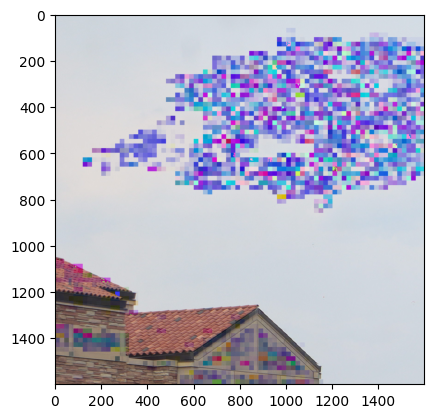

In [72]:
# THe line is a really bad fit on some of them, maybe try using a normal linear regression or something

# Actually iterating through the image
for row in range(0, patch_size*40*2, patch_size):#len(image[0]), patch_size):
    for col in range(0, patch_size*40*2, patch_size*2): #len(image), patch_size*2):
        # print(row, col)
        patch_one = image[row:row+patch_size,col:col+patch_size]
        patch_two = image[row:row+patch_size,col+patch_size: col+patch_size*2]

        print(avg_brightness(patch_one))
        
        if (avg_brightness(patch_one) > 50 or avg_brightness(patch_two)>50):
            # l1 = lobf(patch_one)[0]
            # l2 = lobf(patch_two)[0]
            l1 = polyfit(patch_one)
            l2 = polyfit(patch_two)

            A_hat = airlight_direction(l1, l2)
            a_1 = airlight_mag(l1)
            a_2 = airlight_mag(l2)
            
            # print(A_hat)
            # print(a_1, a_2, row, col)
            image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, a_1)
            image[row:row+patch_size,col+patch_size:col+patch_size*2] = apply_shift(patch_two, A_hat, a_2)

    
plt.imshow(image[:patch_size*40*2, :patch_size*40*2])




In [65]:
print(patch_one[0][0])
print(avg_brightness(patch_one))

[ 77 193 212]
75.98499999999997


C:\Users\cct22\AppData\Local\Temp\ipykernel_19976\1774324836.py:86: RuntimeWarning: overflow encountered in scalar add
  temp.append(sum(patch[i][j])/3)
